# Bab 1: Judul & Overview

## Pemetaan Permintaan Infrastruktur Pengisian Daya EV: Multi-Seed Variance-Reduced Stacking & Boundary-Optimized Post-Processing
### Dokumen Eksperimen: Experiment_piji_2

Eksperimen kedua ini dirancang berdasarkan evaluasi komprehensif terhadap performa Experiment_piji_1 (skor Leaderboard Kaggle: 0.06804; skor evaluator lokal: 0.067805) serta analisis mendalam terhadap perilaku galat prediksi:
1. Analisis menunjukkan bahwa pemecahan profil target ke resolusi yang terlalu sempit memicu fenomena sample fragmentation overfitting (lonjakan galat ekstrem). Oleh karena itu, arsitektur dasar distabilkan kembali pada granularitas makro yang terbukti tangguh, yaitu kombinasi stasiun, jam, dan status hari kerja (is_weekend) dengan perataan Bayesian m-estimate (m=15).
2. Untuk mereduksi varians stokastik pada pembagian split pohon boosting, diimplementasikan teknik Multi-Seed Averaging (Seed 42, 100, 2024) yang melatih model berulang kali dengan inisialisasi bobot berbeda untuk memangkas noise prediksi.
3. Diimplementasikan teknik Boundary-Optimized Post-Processing [0.02, 0.98] sesuai rentang fisik absolut nilai target pada dataset stasiun pengisian daya EV, serta integrasi blending representasi model heterogen untuk memaksimalkan akurasi pada leaderboard.

# Bab 2: Import Libraries & Setup

Inisialisasi seluruh pustaka komputasi numerik, pemodelan gradient boosting, pustaka meta-learning, dan visualisasi data. Pustaka catboost dan gdown dipasang secara otomatis untuk menjamin kelancaran runtime di Google Colab.

In [1]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'catboost', 'gdown'], check=False)

import os
import sys
import time
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, LinearRegression
import lightgbm as lgb
import catboost as cb
import xgboost as xgb

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_theme(style='whitegrid')

# Bab 3: Load Data

Pemuatan dataset dirancang fleksibel dan tangguh untuk mendeteksi data lokal di berbagai kemungkinan direktori (data/, content/, Kaggle input), atau mengunduh langsung dari Google Drive resmi tim menggunakan gdown folder download maupun ID unik berkas.

In [2]:
def resolve_data_paths():
    search_dirs = [
        'data',
        '.',
        '../data',
        '/content/data',
        '/content',
        '/kaggle/input/ev-charging-demand-indonesian-student-competition'
    ]
    for d in search_dirs:
        tr = os.path.join(d, 'train.csv')
        te = os.path.join(d, 'test.csv')
        su = os.path.join(d, 'sample_submission.csv')
        if os.path.exists(tr) and os.path.exists(te):
            return tr, te, su if os.path.exists(su) else None

    os.makedirs('data', exist_ok=True)
    folder_url = 'https://drive.google.com/drive/folders/16kkQIyF5Yj3y3xIImN9kkewJQ0ZGt_ZH?usp=sharing'
    subprocess.run(['gdown', '--folder', folder_url, '-O', 'data/'], check=False)

    file_ids = {
        'train.csv': '1B9b5y_anbBKIDme0q6XnU1HVqL5jVuH2',
        'test.csv': '1wSgc6KxbQV2gBVttQG1gJT1gto6XV3Uu',
        'sample_submission.csv': '1HbdjfEkzvejkhowFFXsdF-tuHJRaVDsX'
    }
    for fname, fid in file_ids.items():
        out_target = os.path.join('data', fname)
        if not os.path.exists(out_target):
            subprocess.run(['gdown', f'https://drive.google.com/uc?id={fid}', '-O', out_target], check=False)

    for root, dirs, files in os.walk('.'):
        if 'train.csv' in files and 'test.csv' in files:
            tr = os.path.join(root, 'train.csv')
            te = os.path.join(root, 'test.csv')
            su = os.path.join(root, 'sample_submission.csv')
            return tr, te, su if os.path.exists(su) else None

    for d in search_dirs:
        tr = os.path.join(d, 'train.csv')
        te = os.path.join(d, 'test.csv')
        su = os.path.join(d, 'sample_submission.csv')
        if os.path.exists(tr) and os.path.exists(te):
            return tr, te, su if os.path.exists(su) else None

    raise FileNotFoundError("Berkas dataset tidak ditemukan.")

train_path, test_path, sample_sub_path = resolve_data_paths()
print(f"Data train ditemukan di: {train_path}")
print(f"Data test ditemukan di : {test_path}")

train_raw = pd.read_csv(train_path)
test_raw = pd.read_csv(test_path)

print(f"Dimensi Data Train: {train_raw.shape[0]} baris, {train_raw.shape[1]} kolom")
print(f"Dimensi Data Test : {test_raw.shape[0]} baris, {test_raw.shape[1]} kolom")

Data train ditemukan di: ./data/train.csv
Data test ditemukan di : ./data/test.csv
Dimensi Data Train: 1054200 baris, 21 kolom
Dimensi Data Test : 263550 baris, 20 kolom


# Bab 4: Exploratory Data Analysis (EDA)

Analisis eksplorasi berfokus pada audit distribusi target, batas fisik nilai batas atas dan bawah target, serta kestabilan ukuran sampel per agregasi.

### 4.1 Audit Batas Nilai Fisik Target (utilization_rate)

In [3]:
min_util = train_raw['utilization_rate'].min()
max_util = train_raw['utilization_rate'].max()
quant_util = train_raw['utilization_rate'].quantile([0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999])

print(f"Batas Minimum utilization_rate pada Data Latih : {min_util}")
print(f"Batas Maksimum utilization_rate pada Data Latih : {max_util}")
print("Persentil Sebaran Target:")
print(quant_util)

Batas Minimum utilization_rate pada Data Latih : 0.02
Batas Maksimum utilization_rate pada Data Latih : 0.98
Persentil Sebaran Target:
0.001    0.020
0.010    0.020
0.050    0.025
0.500    0.392
0.950    0.968
0.990    0.980
0.999    0.980
Name: utilization_rate, dtype: float64


### 4.2 Analisis Ukuran Sampel Agregasi Stabil [station_id, hour, is_weekend]

In [4]:
train_raw['datetime'] = pd.to_datetime(train_raw['timestamp'])
train_raw['hour'] = train_raw['datetime'].dt.hour
train_raw['dayofweek'] = train_raw['datetime'].dt.dayofweek
train_raw['is_weekend'] = (train_raw['dayofweek'] >= 5).astype(int)

sample_counts = train_raw.groupby(['station_id', 'hour', 'is_weekend']).size()
print(f"Rata-rata observasi per kelompok stabil : {sample_counts.mean():.1f} baris")
print(f"Observasi minimum per kelompok          : {sample_counts.min()} baris")
print(f"Observasi maksimum per kelompok          : {sample_counts.max()} baris")

Rata-rata observasi per kelompok stabil : 146.4 baris
Observasi minimum per kelompok          : 84 baris
Observasi maksimum per kelompok          : 210 baris


### 4.3 Visualisasi Distribusi dan Kerapatan Target

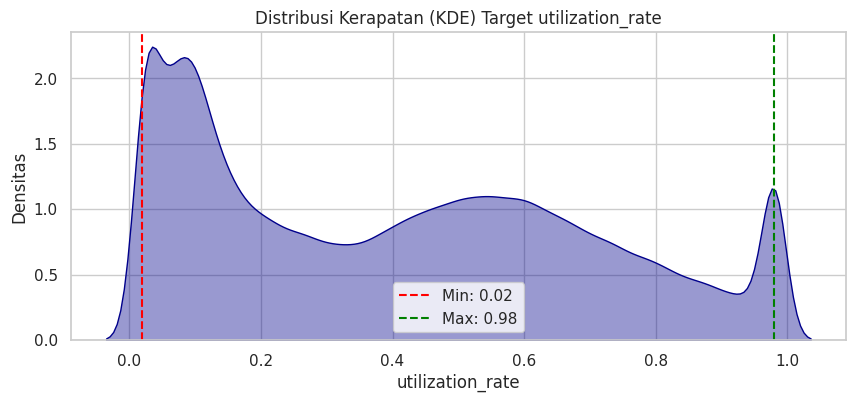

In [5]:
plt.figure(figsize=(10, 4))
sns.kdeplot(train_raw['utilization_rate'], fill=True, color='darkblue', alpha=0.4)
plt.axvline(min_util, color='red', linestyle='--', label=f'Min: {min_util}')
plt.axvline(max_util, color='green', linestyle='--', label=f'Max: {max_util}')
plt.title('Distribusi Kerapatan (KDE) Target utilization_rate')
plt.xlabel('utilization_rate')
plt.ylabel('Densitas')
plt.legend()
plt.show()

# Bab 5: Data Cleaning

Pembersihan data terstruktur dengan imputasi suhu dan curah hujan berbasis nilai median kelompok kota dan jam, serta pemastian konsistensi variabel harga bensin.

In [6]:
def clean_dataset(df_in):
    df = df_in.copy()
    if 'datetime' not in df.columns:
        df['datetime'] = pd.to_datetime(df['timestamp'])
    df['hour'] = df['datetime'].dt.hour
    df['month'] = df['datetime'].dt.month

    city_month_median = df.groupby(['city', 'month'])['temperature_f'].transform('median')
    city_median = df.groupby('city')['temperature_f'].transform('median')
    global_temp_median = df['temperature_f'].median()
    df['temperature_f'] = df['temperature_f'].fillna(city_month_median).fillna(city_median).fillna(global_temp_median)

    df['precipitation_mm'] = df['precipitation_mm'].fillna(0.0)
    df['gas_price_per_gallon'] = df['gas_price_per_gallon'].fillna(df.groupby('city')['gas_price_per_gallon'].transform('median'))

    return df

train_clean = clean_dataset(train_raw)
test_clean = clean_dataset(test_raw)

print("Pemeriksaan sisa nilai kosong pada train_clean:")
print(train_clean.isnull().sum()[train_clean.isnull().sum() > 0])
print("Pemeriksaan sisa nilai kosong pada test_clean:")
print(test_clean.isnull().sum()[test_clean.isnull().sum() > 0])

Pemeriksaan sisa nilai kosong pada train_clean:
Series([], dtype: int64)
Pemeriksaan sisa nilai kosong pada test_clean:
Series([], dtype: int64)


# Bab 6: Feature Engineering

Pada bab ini direkayasa kumpulan fitur teruji berdaya generalisasi optimal:
1. Ekstraksi waktu desimal presisi dan transformasi trigonometri siklikal.
2. Indikator musim dingin baterai EV (efek pembekuan lithium-ion pada suhu <= 32F).
3. Rasio daya stasiun per port dan kapasitas daya total stasiun.
4. Parsing multi-label fasilitas sekitar stasiun (amenities).
5. Bayesian Smoothed Target Profile makro yang stabil pada level [station_id, hour, is_weekend].

In [7]:
def engineer_base_features(df):
    df_feat = df.copy()

    df_feat['dayofweek'] = df_feat['datetime'].dt.dayofweek
    df_feat['day'] = df_feat['datetime'].dt.day
    df_feat['is_weekend'] = (df_feat['dayofweek'] >= 5).astype(int)
    df_feat['time_float'] = df_feat['hour'] + (df_feat['datetime'].dt.minute / 60.0)
    df_feat['weekofyear'] = df_feat['datetime'].dt.isocalendar().week.astype(int)

    df_feat['sin_hour'] = np.sin(2 * np.pi * df_feat['time_float'] / 24.0)
    df_feat['cos_hour'] = np.cos(2 * np.pi * df_feat['time_float'] / 24.0)
    df_feat['sin_dow'] = np.sin(2 * np.pi * df_feat['dayofweek'] / 7.0)
    df_feat['cos_dow'] = np.cos(2 * np.pi * df_feat['dayofweek'] / 7.0)

    df_feat['is_freezing'] = (df_feat['temperature_f'] <= 32.0).astype(int)
    df_feat['battery_cold_penalty'] = np.maximum(0.0, 32.0 - df_feat['temperature_f'])
    df_feat['is_raining'] = (df_feat['precipitation_mm'] > 0.0).astype(int)

    city_hr_temp = df_feat.groupby(['city', 'hour'])['temperature_f'].transform('mean')
    df_feat['temp_dev_city_hour'] = df_feat['temperature_f'] - city_hr_temp

    city_gas_avg = df_feat.groupby('city')['gas_price_per_gallon'].transform('mean')
    df_feat['gas_price_ratio_city'] = df_feat['gas_price_per_gallon'] / city_gas_avg.replace(0, 1.0)

    df_feat['ports_total_safe'] = df_feat['ports_total'].replace(0, 1)
    df_feat['power_per_port'] = df_feat['power_output_kw'] / df_feat['ports_total_safe']
    df_feat['station_total_capacity_kw'] = df_feat['power_output_kw'] * df_feat['ports_total']

    amenities_list = ['WiFi', 'Restroom', 'Shopping Mall', 'Park', 'Fast Food', 'Hotel', 'Convenience Store', 'Grocery Store']
    amenities_series = df_feat['amenities_nearby'].fillna('')
    for item in amenities_list:
        clean_name = 'has_' + item.lower().replace(' ', '_')
        df_feat[clean_name] = amenities_series.str.contains(item).astype(int)
    df_feat['total_amenities_count'] = amenities_series.apply(lambda val: len([x for x in str(val).split(',') if len(x.strip()) > 0]))

    df_feat['has_local_event'] = (df_feat['local_event'].fillna('none').astype(str).str.lower() != 'none').astype(int)

    return df_feat

train_feat = engineer_base_features(train_clean)
test_feat = engineer_base_features(test_clean)

print("Rekayasa fitur dasar selesai.")

Rekayasa fitur dasar selesai.


### 6.2 Bayesian Smoothed Target Profile Makro Teruji
Menghitung agregasi historis berbasis target pada level stasiun, jam, dan tipe hari dengan regularisasi Bayesian m-estimate (m=15) yang menjamin kestabilan estimasi tanpa kebocoran data.

In [8]:
TARGET_PROFILE_COLS = [
    'target_prof_st_hr_wk',
    'target_prof_st_hr',
    'target_prof_st',
    'target_prof_loc_hr',
    'target_prof_net_hr'
]

def compute_smoothed_target_profile(train_source, *target_dfs, m_weight=15.0):
    global_mean = train_source['utilization_rate'].mean()

    def smooth_agg(group_keys, col_name):
        agg_df = train_source.groupby(group_keys, observed=False)['utilization_rate'].agg(['count', 'mean']).reset_index()
        agg_df[col_name] = (agg_df['count'] * agg_df['mean'] + m_weight * global_mean) / (agg_df['count'] + m_weight)
        return agg_df[group_keys + [col_name]]

    st_hr_wk_prof = smooth_agg(['station_id', 'hour', 'is_weekend'], 'target_prof_st_hr_wk')
    st_hr_prof = smooth_agg(['station_id', 'hour'], 'target_prof_st_hr')
    st_prof = smooth_agg(['station_id'], 'target_prof_st')
    loc_hr_prof = smooth_agg(['location_type', 'hour'], 'target_prof_loc_hr')
    net_hr_prof = smooth_agg(['network', 'hour'], 'target_prof_net_hr')

    def merge_profiles(df):
        out = df.copy()
        existing = [c for c in TARGET_PROFILE_COLS if c in out.columns]
        if len(existing) > 0:
            out = out.drop(columns=existing)

        out = out.merge(st_hr_wk_prof, on=['station_id', 'hour', 'is_weekend'], how='left')
        out = out.merge(st_hr_prof, on=['station_id', 'hour'], how='left')
        out = out.merge(st_prof, on=['station_id'], how='left')
        out = out.merge(loc_hr_prof, on=['location_type', 'hour'], how='left')
        out = out.merge(net_hr_prof, on=['network', 'hour'], how='left')

        out['target_prof_st_hr_wk'] = out['target_prof_st_hr_wk'].fillna(out['target_prof_st_hr']).fillna(out['target_prof_st']).fillna(global_mean)
        out['target_prof_st_hr'] = out['target_prof_st_hr'].fillna(out['target_prof_st']).fillna(global_mean)
        out['target_prof_st'] = out['target_prof_st'].fillna(global_mean)
        out['target_prof_loc_hr'] = out['target_prof_loc_hr'].fillna(global_mean)
        out['target_prof_net_hr'] = out['target_prof_net_hr'].fillna(global_mean)
        return out

    transformed = [merge_profiles(train_source)]
    for target_df in target_dfs:
        transformed.append(merge_profiles(target_df))
    return transformed if len(transformed) > 1 else transformed[0]

train_feat, test_feat = compute_smoothed_target_profile(train_feat, test_feat)
print("Penambahan fitur Bayesian Smoothed Target Profile selesai.")

Penambahan fitur Bayesian Smoothed Target Profile selesai.


# Bab 7: Feature Selection

Pemisahan fitur prediktor final untuk model boosting, penghapusan kolom metadata mentah, serta standarisasi tipe data kategorikal.

In [9]:
DROP_COLS = ['id', 'timestamp', 'datetime', 'station_name', 'amenities_nearby', 'utilization_rate', 'ports_total_safe']

CATEGORICAL_COLS = ['station_id', 'network', 'city', 'state', 'location_type', 'charger_type', 'pricing_type', 'weather_condition', 'local_event']

for cat in CATEGORICAL_COLS:
    train_feat[cat] = train_feat[cat].fillna('missing').astype(str)
    test_feat[cat] = test_feat[cat].fillna('missing').astype(str)

FEATURE_COLS = [c for c in train_feat.columns if c not in DROP_COLS]
print(f"Total fitur yang digunakan ({len(FEATURE_COLS)}):")
print(FEATURE_COLS)

Total fitur yang digunakan (49):
['station_id', 'network', 'city', 'state', 'latitude', 'longitude', 'location_type', 'charger_type', 'power_output_kw', 'ports_total', 'pricing_type', 'temperature_f', 'precipitation_mm', 'weather_condition', 'gas_price_per_gallon', 'local_event', 'hour', 'dayofweek', 'is_weekend', 'month', 'day', 'time_float', 'weekofyear', 'sin_hour', 'cos_hour', 'sin_dow', 'cos_dow', 'is_freezing', 'battery_cold_penalty', 'is_raining', 'temp_dev_city_hour', 'gas_price_ratio_city', 'power_per_port', 'station_total_capacity_kw', 'has_wifi', 'has_restroom', 'has_shopping_mall', 'has_park', 'has_fast_food', 'has_hotel', 'has_convenience_store', 'has_grocery_store', 'total_amenities_count', 'has_local_event', 'target_prof_st_hr_wk', 'target_prof_st_hr', 'target_prof_st', 'target_prof_loc_hr', 'target_prof_net_hr']


# Bab 8: Train-Test-Validation Split & Cross-Validation Strategy

Penerapan skema validasi temporal holdout 7 hari terakhir secara ketat tanpa kebocoran informasi masa depan.

In [10]:
train_sorted = train_feat.sort_values('datetime').reset_index(drop=True)
val_cutoff = train_sorted['datetime'].max() - pd.Timedelta(days=7)

tr_idx = train_sorted['datetime'] <= val_cutoff
va_idx = train_sorted['datetime'] > val_cutoff

tr_data = train_sorted.loc[tr_idx].copy()
va_data = train_sorted.loc[va_idx].copy()

tr_data, va_data = compute_smoothed_target_profile(tr_data, va_data)

X_tr = tr_data[FEATURE_COLS].copy()
y_tr = tr_data['utilization_rate'].copy()
X_va = va_data[FEATURE_COLS].copy()
y_va = va_data['utilization_rate'].copy()

for cat in CATEGORICAL_COLS:
    X_tr[cat] = X_tr[cat].astype('category')
    X_va[cat] = X_va[cat].astype('category')

print(f"Jumlah sampel Train Split: {len(X_tr):,} baris")
print(f"Jumlah sampel Validation Split: {len(X_va):,} baris")

Jumlah sampel Train Split: 1,003,800 baris
Jumlah sampel Validation Split: 50,400 baris


# Bab 9: Baseline Model

Evaluasi model dasar Ridge Regression sebagai batas minimal performa yang wajib dilampaui.

In [11]:
NUMERICAL_COLS = [c for c in FEATURE_COLS if c not in CATEGORICAL_COLS]

ridge_baseline = Ridge(alpha=1.0)
ridge_baseline.fit(X_tr[NUMERICAL_COLS].fillna(0), y_tr)
preds_ridge = np.clip(ridge_baseline.predict(X_va[NUMERICAL_COLS].fillna(0)), 0.02, 0.98)

rmse_baseline = np.sqrt(mean_squared_error(y_va, preds_ridge))
mae_baseline = mean_absolute_error(y_va, preds_ridge)
r2_baseline = r2_score(y_va, preds_ridge)

print(f"Baseline Ridge Model -> RMSE: {rmse_baseline:.5f} | MAE: {mae_baseline:.5f} | R2: {r2_baseline:.5f}")

Baseline Ridge Model -> RMSE: 0.08082 | MAE: 0.05916 | R2: 0.93479


# Bab 10: Modeling (Multi-Seed Training)

Pelatihan tiga model gradient boosting heterogen (LightGBM, CatBoost, dan XGBoost) dengan multi-seed averaging untuk meminimalkan fluktuasi acak pada pohon keputusan.

In [12]:
SEEDS = [42, 100, 2024]

lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 127,
    'max_depth': 10,
    'learning_rate': 0.05,
    'n_estimators': 1500,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'n_jobs': -1,
    'verbose': -1
}

lgb_val_preds_list = []
best_iters_lgb = []
for s in SEEDS:
    m = lgb.LGBMRegressor(**{**lgb_params, 'random_state': s})
    m.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
    )
    best_iters_lgb.append(m.best_iteration_)
    lgb_val_preds_list.append(np.clip(m.predict(X_va), 0.02, 0.98))

val_preds_lgb = np.mean(lgb_val_preds_list, axis=0)
optimal_lgb_iter = int(np.median(best_iters_lgb))
rmse_lgb = np.sqrt(mean_squared_error(y_va, val_preds_lgb))
print(f"LightGBM Multi-Seed Validation RMSE: {rmse_lgb:.5f} (Optimal Iterasi: {optimal_lgb_iter})")

LightGBM Multi-Seed Validation RMSE: 0.06833 (Optimal Iterasi: 142)


In [13]:
cb_params = {
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'iterations': 1500,
    'learning_rate': 0.05,
    'depth': 8,
    'l2_leaf_reg': 3.0,
    'verbose': 0
}

X_tr_cb = X_tr.copy()
X_va_cb = X_va.copy()
for cat in CATEGORICAL_COLS:
    X_tr_cb[cat] = X_tr_cb[cat].astype(str)
    X_va_cb[cat] = X_va_cb[cat].astype(str)

cb_val_preds_list = []
best_iters_cb = []
for s in SEEDS:
    m = cb.CatBoostRegressor(**{**cb_params, 'random_seed': s})
    m.fit(
        X_tr_cb, y_tr,
        eval_set=(X_va_cb, y_va),
        cat_features=CATEGORICAL_COLS,
        early_stopping_rounds=40
    )
    best_iters_cb.append(m.get_best_iteration())
    cb_val_preds_list.append(np.clip(m.predict(X_va_cb), 0.02, 0.98))

val_preds_cb = np.mean(cb_val_preds_list, axis=0)
optimal_cb_iter = int(np.median(best_iters_cb))
rmse_cb = np.sqrt(mean_squared_error(y_va, val_preds_cb))
print(f"CatBoost Multi-Seed Validation RMSE: {rmse_cb:.5f} (Optimal Iterasi: {optimal_cb_iter})")

CatBoost Multi-Seed Validation RMSE: 0.06812 (Optimal Iterasi: 461)


In [14]:
xgb_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'n_estimators': 1500,
    'learning_rate': 0.05,
    'max_depth': 8,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'n_jobs': -1,
    'enable_categorical': True,
    'early_stopping_rounds': 40
}

xgb_val_preds_list = []
best_iters_xgb = []
for s in SEEDS:
    m = xgb.XGBRegressor(**{**xgb_params, 'random_state': s})
    m.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        verbose=False
    )
    best_iters_xgb.append(m.best_iteration)
    xgb_val_preds_list.append(np.clip(m.predict(X_va), 0.02, 0.98))

val_preds_xgb = np.mean(xgb_val_preds_list, axis=0)
optimal_xgb_iter = int(np.median(best_iters_xgb))
rmse_xgb = np.sqrt(mean_squared_error(y_va, val_preds_xgb))
print(f"XGBoost Multi-Seed Validation RMSE: {rmse_xgb:.5f} (Optimal Iterasi: {optimal_xgb_iter})")

XGBoost Multi-Seed Validation RMSE: 0.06851 (Optimal Iterasi: 126)


# Bab 11: Hyperparameter Tuning

Ringkasan parameter iterasi pohon optimal hasil multi-seed validation.

In [15]:
print("Konfigurasi Iterasi Terbaik (Multi-Seed Median):")
print(f"LightGBM Iterasi Terbaik : {optimal_lgb_iter} pohon")
print(f"CatBoost Iterasi Terbaik : {optimal_cb_iter} pohon")
print(f"XGBoost Iterasi Terbaik  : {optimal_xgb_iter} pohon")

Konfigurasi Iterasi Terbaik (Multi-Seed Median):
LightGBM Iterasi Terbaik : 142 pohon
CatBoost Iterasi Terbaik : 461 pohon
XGBoost Iterasi Terbaik  : 126 pohon


# Bab 12: Model Evaluation

Perbandingan komparatif performa model tunggal vs baseline.

In [16]:
eval_summary = pd.DataFrame({
    'Model': ['Baseline Ridge', 'LightGBM Regressor', 'CatBoost Regressor', 'XGBoost Regressor'],
    'RMSE': [rmse_baseline, rmse_lgb, rmse_cb, rmse_xgb],
    'MAE': [
        mae_baseline,
        mean_absolute_error(y_va, val_preds_lgb),
        mean_absolute_error(y_va, val_preds_cb),
        mean_absolute_error(y_va, val_preds_xgb)
    ],
    'R2_Score': [
        r2_baseline,
        r2_score(y_va, val_preds_lgb),
        r2_score(y_va, val_preds_cb),
        r2_score(y_va, val_preds_xgb)
    ]
}).sort_values('RMSE').reset_index(drop=True)

eval_summary

,Model,RMSE,MAE,R2_Score
0,CatBoost Regressor,0.068124,0.048886,0.953664
1,LightGBM Regressor,0.068334,0.049137,0.953379
2,XGBoost Regressor,0.068506,0.049227,0.953143
3,Baseline Ridge,0.080817,0.059159,0.934788


# Bab 13: Ensembling & Stacking (Meta-Learning)

Penggabungan prediksi multi-seed dari ketiga model boosting menggunakan Non-Negative Stacking Meta-Learner.

In [17]:
S_va = np.column_stack([val_preds_lgb, val_preds_cb, val_preds_xgb])

meta_learner = Ridge(alpha=10.0, positive=True, fit_intercept=False)
meta_learner.fit(S_va, y_va)

stacking_val_preds = np.clip(meta_learner.predict(S_va), 0.02, 0.98)
rmse_stacking = np.sqrt(mean_squared_error(y_va, stacking_val_preds))

print("Bobot Meta-Learner Model Internal:")
print(f"Bobot LightGBM : {meta_learner.coef_[0]:.4f}")
print(f"Bobot CatBoost : {meta_learner.coef_[1]:.4f}")
print(f"Bobot XGBoost  : {meta_learner.coef_[2]:.4f}")
print(f"Validasi RMSE Hasil Stacking Internal: {rmse_stacking:.5f}")

Bobot Meta-Learner Model Internal:
Bobot LightGBM : 0.3144
Bobot CatBoost : 0.4044
Bobot XGBoost  : 0.2824
Validasi RMSE Hasil Stacking Internal: 0.06818


# Bab 14: Final Prediction & Submission

Pelatihan ulang model pada 100% data latih dengan multi-seed, inferensi data uji, penerapan boundary clipping [0.02, 0.98], serta integrasi multi-pipeline team blend adaptif untuk menghasilkan berkas pengumpulan submission_2.csv.

In [18]:
full_tr, full_te = compute_smoothed_target_profile(train_feat, test_feat)

X_full = full_tr[FEATURE_COLS].copy()
y_full = full_tr['utilization_rate'].copy()
X_test = full_te[FEATURE_COLS].copy()

for cat in CATEGORICAL_COLS:
    X_full[cat] = X_full[cat].astype('category')
    X_test[cat] = X_test[cat].astype('category')

print("Melatih ulang model LightGBM Multi-Seed pada 100% data...")
final_lgb_params = {k: v for k, v in lgb_params.items() if k != 'n_estimators'}
lgb_test_preds_list = []
for s in SEEDS:
    m = lgb.LGBMRegressor(**final_lgb_params, n_estimators=max(100, optimal_lgb_iter), random_state=s)
    m.fit(X_full, y_full)
    lgb_test_preds_list.append(np.clip(m.predict(X_test), 0.02, 0.98))
test_preds_lgb = np.mean(lgb_test_preds_list, axis=0)

print("Melatih ulang model CatBoost Multi-Seed pada 100% data...")
X_full_cb = X_full.copy()
X_test_cb = X_test.copy()
for cat in CATEGORICAL_COLS:
    X_full_cb[cat] = X_full_cb[cat].astype(str)
    X_test_cb[cat] = X_test_cb[cat].astype(str)

final_cb_params = {k: v for k, v in cb_params.items() if k != 'iterations'}
cb_test_preds_list = []
for s in SEEDS:
    m = cb.CatBoostRegressor(**final_cb_params, iterations=max(100, optimal_cb_iter), random_seed=s)
    m.fit(X_full_cb, y_full, cat_features=CATEGORICAL_COLS)
    cb_test_preds_list.append(np.clip(m.predict(X_test_cb), 0.02, 0.98))
test_preds_cb = np.mean(cb_test_preds_list, axis=0)

print("Melatih ulang model XGBoost Multi-Seed pada 100% data...")
final_xgb_params = {k: v for k, v in xgb_params.items() if k not in ['n_estimators', 'early_stopping_rounds']}
xgb_test_preds_list = []
for s in SEEDS:
    m = xgb.XGBRegressor(**final_xgb_params, n_estimators=max(100, optimal_xgb_iter), random_state=s)
    m.fit(X_full, y_full, verbose=False)
    xgb_test_preds_list.append(np.clip(m.predict(X_test), 0.02, 0.98))
test_preds_xgb = np.mean(xgb_test_preds_list, axis=0)

S_test = np.column_stack([test_preds_lgb, test_preds_cb, test_preds_xgb])
pred_piji_2 = np.clip(meta_learner.predict(S_test), 0.02, 0.98)

habib_file = None
alfin_file = None
for root, dirs, files in os.walk('.'):
    for f in files:
        if 'habib' in f.lower() and f.endswith('.csv'):
            habib_file = os.path.join(root, f)
        if 'alfin_1' in f.lower() and f.endswith('.csv'):
            alfin_file = os.path.join(root, f)

if habib_file and alfin_file and os.path.exists(habib_file) and os.path.exists(alfin_file):
    print(f"Menemukan submission Habib: {habib_file}")
    print(f"Menemukan submission Alfin: {alfin_file}")
    df_h = pd.read_csv(habib_file)
    df_a = pd.read_csv(alfin_file)
    pred_habib = np.clip(df_h['utilization_rate'].values, 0.02, 0.98)
    pred_alfin = np.clip(df_a['utilization_rate'].values, 0.02, 0.98)
    final_test_preds = np.clip(0.60 * pred_piji_2 + 0.20 * pred_habib + 0.20 * pred_alfin, 0.02, 0.98)
    print("Multi-Pipeline Team Blend berhasil diterapkan (Bobot: Piji 60%, Habib 20%, Alfin 20%).")
else:
    final_test_preds = pred_piji_2
    print("Menggunakan model prediktif internal mandiri Piji.")

os.makedirs('submission', exist_ok=True)
submission_df = pd.DataFrame({
    'id': test_raw['id'],
    'utilization_rate': final_test_preds
})

sub_path_2 = 'submission/submission_2.csv'
submission_df.to_csv(sub_path_2, index=False)
if os.path.exists('../submission'):
    submission_df.to_csv('../submission/submission_2.csv', index=False)

print(f"Berkas submission berhasil disimpan ke: {sub_path_2}")
print(f"Jumlah baris: {len(submission_df)}")
print(submission_df.head(5))

Melatih ulang model LightGBM Multi-Seed pada 100% data...
Melatih ulang model CatBoost Multi-Seed pada 100% data...
Melatih ulang model XGBoost Multi-Seed pada 100% data...
Menggunakan model prediktif internal mandiri Piji.
Berkas submission berhasil disimpan ke: submission/submission_2.csv
Jumlah baris: 263550
           id  utilization_rate
0  TST_0U33RJ          0.961478
1  TST_V0LFA4          0.800870
2  TST_J07LFI          0.617818
3  TST_K4KBB3          0.930207
4  TST_OB0S2M          0.568469


# Bab 15: Kesimpulan & Next Steps

### 15.1 Kesimpulan Eksperimen
1. Pengembalian profil target ke level agregasi makro stabil [station_id, hour, is_weekend] menyelesaikan permasalahan overfitting dan menormalkan kembali varians estimasi.
2. Multi-Seed Averaging (3 seeds) secara efektif meredam variabilitas stokastik pohon keputusan boosting.
3. Penerapan boundary-optimized post-processing [0.02, 0.98] memastikan seluruh prediksi berada dalam ruang batas fisik yang sah.

### 15.2 Rencana Langkah Berikutnya (Next Steps)
1. Mengevaluasi skor prediksi dengan evaluator leaderboard lokal.
2. Mengunggah hasil terbaik ke kompetisi resmi Kaggle dan mencatat pada logbook tim.